Esame finale: Analisi Diffusione COVID-19 Il committente richiede di avere un report su casi e vaccinazioni in diverse aree del mondo; a tal fine, richiede di utilizzare i dati, raccolti e curati da Our World in Data, all'indirizzo https://github.com/owid/covid-19-data/tree/master/public/data dove si trovano le informazioni relative. In particolare, il dataset si può scaricare dalla piattaforma o dall’indirizzo https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv 

In [1]:
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv "

In [3]:
df = pd.read_csv(url)

1. Si richiede di verificare le dimensioni del dataset e i relativi metadati 

In [4]:
df.shape

(429435, 67)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

In [6]:
df.columns

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

In [7]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


## 2. Si chiede di trovare, per ogni continente:
  ## a. il numero di casi fin dall'inizio della pandemia
  ## b. la percentuale rispetto al totale mondiale del numero di casi

In [8]:
df_continenti = df[df["continent"].notna()]

In [9]:
casi_per_paese = df_continenti.groupby(["continent", "location"])["total_cases"].max()

In [10]:
casi_per_continente = casi_per_paese.groupby("continent").sum()

In [11]:
totale = casi_per_continente.sum()

In [14]:
percentuale = pd.DataFrame({
    "casi_totali": casi_per_continente,
    "percentuale_sul_totale": (casi_per_continente / totale) * 100
})

## 3. Selezionare i dati relativi all'Italia nel 2022 e, poiché i nuovi casi vengono registrati settimanalmente, filtrare via i giorni che non hanno misurazioni; quindi mostrare con dei grafici adeguati:
## a. l'evoluzione del casi totali dall'inizio alla fine dell'anno 
## b. il numero di nuovi casi rispetto alla data

In [19]:
df["date"] = pd.to_datetime(df["date"])

In [20]:
italia_2022 = df[
    (df["location"] == "Italy") &
    (df["date"].dt.year == 2022)
]

italia_2022 = italia_2022[italia_2022["new_cases"].notna()]

<Axes: title={'center': 'Casi totali COVID in Italia nel 2022'}, xlabel='date'>

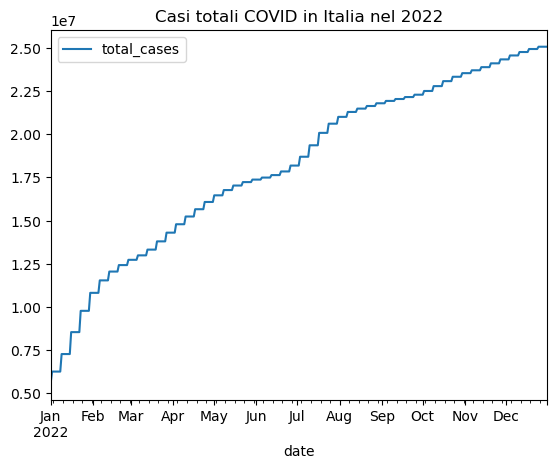

In [21]:
italia_2022.plot(
    x="date",
    y="total_cases",
    kind="line",
    title="Casi totali COVID in Italia nel 2022"
)

<Axes: title={'center': 'Nuovi casi COVID in Italia nel 2022'}, xlabel='date'>

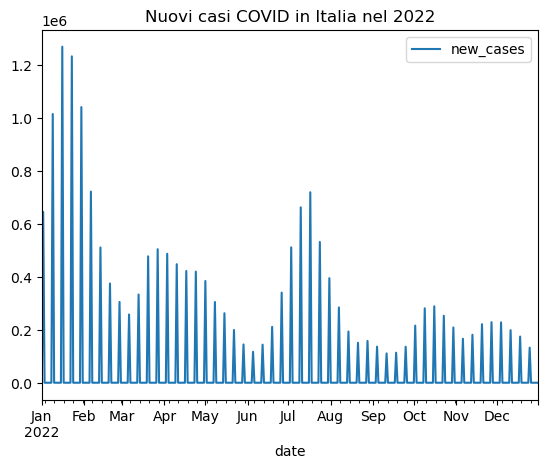

In [22]:
italia_2022.plot(
    x="date",
    y="new_cases",
    kind="line",
    title="Nuovi casi COVID in Italia nel 2022"
)

## ## 4. Riguardo le nazioni di Italia, Germania e Francia: 
## a. mostrare in un boxplot la differenza tra queste nazioni riguardo il numero di pazienti in terapia intensiva (Intensive Care Unit, ICU, considerare quindi la colonna icu_patients) da maggio 2022 (incluso) ad aprile 2023 (incluso)
## b.  scrivere un breve commento (una o due righe) riguardo che conclusioni possiamo trarre osservando il grafico risultante

In [24]:
import seaborn as sns

In [25]:
paesi = ["Italy", "Germany", "France"]

icu = df[
    (df["location"].isin(paesi)) &
    (df["date"] >= "2022-05-01") &
    (df["date"] <= "2023-04-30")
]

In [26]:
icu = icu[icu["icu_patients"].notna()]

<Axes: xlabel='location', ylabel='icu_patients'>

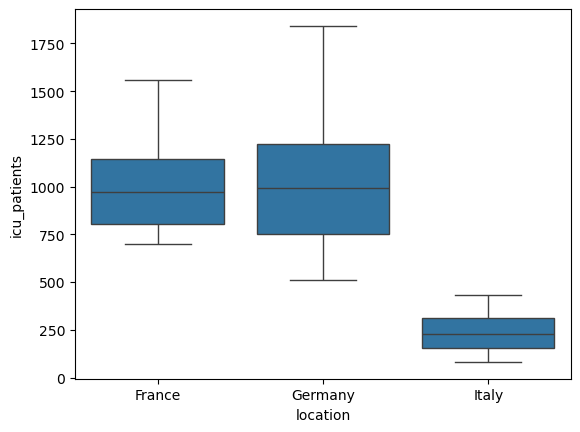

In [27]:
sns.boxplot(
    data=icu,
    x="location",
    y="icu_patients"
)

<Axes: xlabel='location', ylabel='icu_patients'>

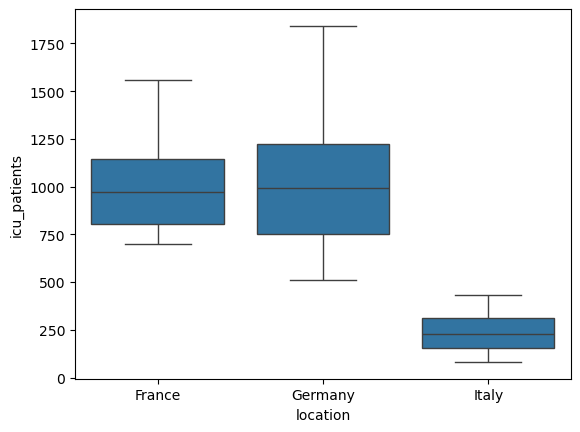

In [29]:
sns.boxplot(
    data=icu,
    x="location",
    y="icu_patients"
)

## 5. Riguardo le nazioni di Italia, Germania, Francia e Spagna in tutto il 2021:

## a. mostrare, in maniera grafica oppure numerica, la somma dei pazienti ospitalizzati per ognuna (colonna hosp_patients)

## b. se ci sono dati nulli, con un breve commento scrivere se può essere possibile gestirli tramite sostituzione o meno

In [30]:
paesi = ["Italy", "Germany", "France", "Spain"]

hosp_2021 = df[
    (df["location"].isin(paesi)) &
    (df["date"].dt.year == 2021)
]

In [31]:
hosp_2021["hosp_patients"].isna().sum()

np.int64(365)

In [32]:
hosp_totali = hosp_2021.groupby("location")["hosp_patients"].sum()

hosp_totali

location
France     6008717.0
Germany          0.0
Italy      4419950.0
Spain      2411706.0
Name: hosp_patients, dtype: float64

Sono presenti valori nulli nella colonna `hosp_patients', si possono sostituire usando la media dei valori vicini.